<a href="https://colab.research.google.com/github/Ansarss/Ai_learning_experiments/blob/main/Predictive_Modeling_in_Marketing_Analytics_Using_Regularized_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install kagglehub[pandas-datasets] -q
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd


In [4]:
file_path = "marketing_AB.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "faviovaz/marketing-ab-testing",
    file_path
)

df.head()

100%|██████████| 5.23M/5.23M [00:00<00:00, 122MB/s]

Extracting zip of marketing_AB.csv...


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (588101, 7)

Columns:
['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads', 'most ads day', 'most ads hour']

Data types:
Unnamed: 0        int64
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object


In [7]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

Duplicate rows: 0


In [8]:
# Remove unnecessary identifier columns
df = df.drop(columns=["Unnamed: 0", "user id"])

# Check the remaining columns
df.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


In [9]:
print(df["converted"].value_counts())

print("\nPercentages:")
print(df["converted"].value_counts(normalize=True) * 100)

converted
False    573258
True      14843
Name: count, dtype: int64

Percentages:
converted
False    97.476114
True      2.523886
Name: proportion, dtype: float64


In [10]:
print("Test group values:")
print(df["test group"].value_counts())

print("\nMost ads day values:")
print(df["most ads day"].value_counts())

print("\nMost ads hour values:")
print(df["most ads hour"].value_counts().sort_index())

Test group values:
test group
ad     564577
psa     23524
Name: count, dtype: int64

Most ads day values:
most ads day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64

Most ads hour values:
most ads hour
0      5536
1      4802
2      5333
3      2679
4       722
5       765
6      2068
7      6405
8     17627
9     31004
10    38939
11    46210
12    47298
13    47655
14    45648
15    44683
16    37567
17    34988
18    32323
19    30352
20    28923
21    29976
22    26432
23    20166
Name: count, dtype: int64


In [11]:
# Convert target variable to 0 and 1
df["converted"] = df["converted"].astype(int)

# One-hot encode categorical variables
df_encoded = pd.get_dummies(
    df,
    columns=["test group", "most ads day"],
    drop_first=True
)

df_encoded.head()

,converted,total ads,most ads hour,test group_psa,most ads day_Monday,most ads day_Saturday,most ads day_Sunday,most ads day_Thursday,most ads day_Tuesday,most ads day_Wednesday
0,0,130,20,False,True,False,False,False,False,False
1,0,93,22,False,False,False,False,False,True,False
2,0,21,18,False,False,False,False,False,True,False
3,0,355,10,False,False,False,False,False,True,False
4,0,276,14,False,False,False,False,False,False,False


In [12]:
print(df_encoded.shape)
print(df_encoded.dtypes)

(588101, 10)
converted                 int64
total ads                 int64
most ads hour             int64
test group_psa             bool
most ads day_Monday        bool
most ads day_Saturday      bool
most ads day_Sunday        bool
most ads day_Thursday      bool
most ads day_Tuesday       bool
most ads day_Wednesday     bool
dtype: object


In [13]:
from sklearn.model_selection import train_test_split

# Separate predictors and target
X = df_encoded.drop(columns=["converted"])
y = df_encoded["converted"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining conversion rate:")
print(y_train.mean())

print("\nTest conversion rate:")
print(y_test.mean())

Training set: (470480, 9)
Test set: (117621, 9)

Training conversion rate:
0.025238054752593095

Test conversion rate:
0.025242091123183784


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_cols = ["total ads", "most ads hour"]

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

X_train_scaled.head()

,total ads,most ads hour,test group_psa,most ads day_Monday,most ads day_Saturday,most ads day_Sunday,most ads day_Thursday,most ads day_Tuesday,most ads day_Wednesday
514503,0.142683,-0.303516,False,False,False,True,False,False,False
426530,-0.293529,-0.096709,False,False,False,False,False,False,False
414308,-0.316488,1.557740,False,False,False,False,False,False,True
574649,-0.523115,0.110097,False,False,True,False,False,False,False
492645,-0.477198,-0.510322,False,False,False,False,False,False,False


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

baseline_model = LogisticRegression(
    penalty=None,
    max_iter=1000
)

baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
y_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    114652
           1       0.20      0.02      0.03      2969

    accuracy                           0.97    117621
   macro avg       0.59      0.51      0.51    117621
weighted avg       0.96      0.97      0.96    117621

ROC-AUC: 0.8172204195355167


In [18]:
from sklearn.linear_model import LogisticRegressionCV

ridge_model = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty="l2",
    solver="liblinear",
    scoring="roc_auc",
    max_iter=1000
)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)
ridge_prob = ridge_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, ridge_pred))
print("ROC-AUC:", roc_auc_score(y_test, ridge_prob))
print("Best C:", ridge_model.C_[0])

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    114652
           1       0.19      0.01      0.03      2969

    accuracy                           0.97    117621
   macro avg       0.58      0.51      0.51    117621
weighted avg       0.96      0.97      0.96    117621

ROC-AUC: 0.8230632971880865
Best C: 0.005994842503189409


In [19]:
lasso_model = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty="l1",
    solver="liblinear",
    scoring="roc_auc",
    max_iter=1000
)

lasso_model.fit(X_train_scaled, y_train)

lasso_pred = lasso_model.predict(X_test_scaled)
lasso_prob = lasso_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, lasso_pred))
print("ROC-AUC:", roc_auc_score(y_test, lasso_prob))
print("Best C:", lasso_model.C_[0])

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    114652
           1       0.19      0.01      0.02      2969

    accuracy                           0.97    117621
   macro avg       0.58      0.51      0.51    117621
weighted avg       0.96      0.97      0.96    117621

ROC-AUC: 0.8569206751640212
Best C: 0.000774263682681127


In [20]:
import pandas as pd
import numpy as np

coef_table = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Lasso Coefficient": lasso_model.coef_[0]
})

coef_table["Absolute Coefficient"] = np.abs(coef_table["Lasso Coefficient"])

coef_table = coef_table.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print(coef_table)

                  Feature  Lasso Coefficient  Absolute Coefficient
0               total ads           0.396258              0.396258
1           most ads hour           0.030705              0.030705
2          test group_psa           0.000000              0.000000
3     most ads day_Monday           0.000000              0.000000
4   most ads day_Saturday           0.000000              0.000000
5     most ads day_Sunday           0.000000              0.000000
6   most ads day_Thursday           0.000000              0.000000
7    most ads day_Tuesday           0.000000              0.000000
8  most ads day_Wednesday           0.000000              0.000000


In [21]:
print("\nFeatures shrunk to zero:")
print(
    coef_table[coef_table["Lasso Coefficient"] == 0]
)


Features shrunk to zero:
                  Feature  Lasso Coefficient  Absolute Coefficient
2          test group_psa                0.0                   0.0
3     most ads day_Monday                0.0                   0.0
4   most ads day_Saturday                0.0                   0.0
5     most ads day_Sunday                0.0                   0.0
6   most ads day_Thursday                0.0                   0.0
7    most ads day_Tuesday                0.0                   0.0
8  most ads day_Wednesday                0.0                   0.0


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Baseline", "Ridge", "Lasso"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, ridge_pred),
        accuracy_score(y_test, lasso_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, ridge_pred),
        precision_score(y_test, lasso_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, ridge_pred),
        recall_score(y_test, lasso_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, ridge_pred),
        f1_score(y_test, lasso_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, ridge_prob),
        roc_auc_score(y_test, lasso_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,0.973610,0.202643,0.015493,0.028786,0.817220
1,Ridge,0.973593,0.192825,0.014483,0.026942,0.823063
2,Lasso,0.973712,0.187817,0.012462,0.023373,0.856921


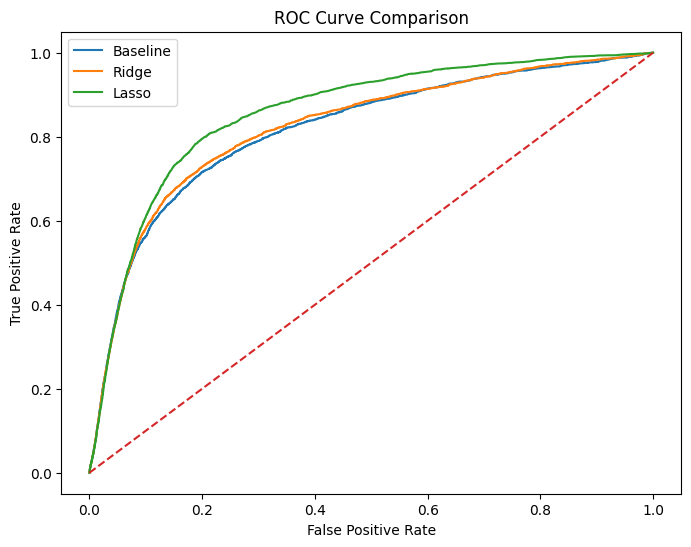

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_base, tpr_base, _ = roc_curve(y_test, y_prob)
fpr_ridge, tpr_ridge, _ = roc_curve(y_test, ridge_prob)
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, lasso_prob)

plt.figure(figsize=(8, 6))

plt.plot(fpr_base, tpr_base, label="Baseline")
plt.plot(fpr_ridge, tpr_ridge, label="Ridge")
plt.plot(fpr_lasso, tpr_lasso, label="Lasso")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

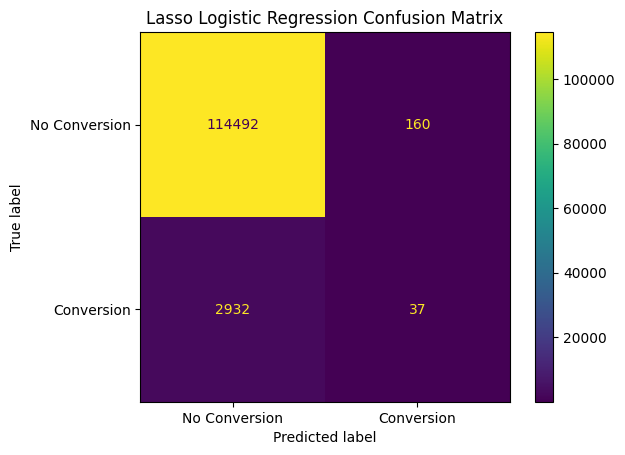

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lasso_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Conversion", "Conversion"]
)

disp.plot()
plt.title("Lasso Logistic Regression Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import average_precision_score

print("Baseline Average Precision:",
      average_precision_score(y_test, y_prob))

print("Ridge Average Precision:",
      average_precision_score(y_test, ridge_prob))

print("Lasso Average Precision:",
      average_precision_score(y_test, lasso_prob))

Baseline Average Precision: 0.12535611847632036
Ridge Average Precision: 0.12666173991866617
Lasso Average Precision: 0.13323774802487234
